Evaluate naive fusion model

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import json

In [2]:
def compute_iou(xmin, ymin, xmax, ymax, xmin2, ymin2, xmax2, ymax2):
    if xmin2 > xmax2 or ymin2 > ymax2:
        return 0
    A1 = (xmax - xmin) * (ymax - ymin)
    A2 = (xmax2 - xmin2) * (ymax2 - ymin2)
    Ai = (min(xmax,xmax2) - max(xmin,xmin2)) * (min(ymax,ymax2) - max(ymin,ymin2))
    if Ai / (A1 + A2 - Ai) < 0:
        pass
        #print((xmin, ymin, xmax, ymax, xmin2, ymin2, xmax2, ymax2))
    return max(0, Ai / (A1 + A2 - Ai))

In [3]:
def get_corners(x_origin, y_origin, height, width):
    xmin = x_origin - (width/2)
    xmax = x_origin + (width/2)
    ymin = y_origin - (height/2)
    ymax = y_origin + (height/2)
    return xmin, ymin, xmax, ymax

In [4]:
with open("../../output/output_obj_altlabel/output.csv", "r") as f:
    baseline_csv = f.readlines()
with open("../../output/fusion/naive.csv", "r") as f:
    naive_csv = f.readlines()
with open("../../output/fusion/naive_altlabel.csv", "r") as f:
    naive_altlabel_csv = f.readlines()

In [8]:
!ls output

output.csv


In [9]:
with open("output/output.csv", "r") as f:
    doubleres_csv = f.readlines()

In [12]:
doubleres_iou = []
for line in doubleres_csv:
    name, label_xmin, label_ymin, label_xmax, label_ymax, xmin, ymin, xmax, ymax = line.split(",")
    ymax = ymax.strip()
    #convert coordinates to int
    label_xmin, label_ymin, label_xmax, label_ymax, xmin, ymin, xmax, ymax = [int(x) for x in [label_xmin, label_ymin, label_xmax, label_ymax, xmin, ymin, xmax, ymax]]
    #xmin, ymin, xmax, ymax = get_corners(xmin, ymin, xmax, ymax)
    #label_xmin, label_ymin, label_xmax, label_ymax = get_corners(label_xmin, label_ymin, label_xmax, label_ymax)
    doubleres_iou.append(compute_iou(label_xmin, label_ymin, label_xmax, label_ymax, xmin, ymin, xmax, ymax))

In [10]:
baseline_iou = []
naive_iou = []
naive_altlabel_iou = []
for line in baseline_csv:
    name, label_xmin, label_ymin, label_xmax, label_ymax, xmin, ymin, xmax, ymax = line.split(",")
    ymax = ymax.strip()
    #convert coordinates to int
    label_xmin, label_ymin, label_xmax, label_ymax, xmin, ymin, xmax, ymax = [int(x) for x in [label_xmin, label_ymin, label_xmax, label_ymax, xmin, ymin, xmax, ymax]]
    xmin, ymin, xmax, ymax = get_corners(xmin, ymin, xmax, ymax)
    label_xmin, label_ymin, label_xmax, label_ymax = get_corners(label_xmin, label_ymin, label_xmax, label_ymax)
    baseline_iou.append(compute_iou(label_xmin, label_ymin, label_xmax, label_ymax, xmin, ymin, xmax, ymax))
for line in naive_csv:
    name, label_xmin, label_ymin, label_xmax, label_ymax, xmin, ymin, xmax, ymax = line.split(",")
    ymax = ymax.strip()
    #convert coordinates to int
    label_xmin, label_ymin, label_xmax, label_ymax, xmin, ymin, xmax, ymax = [int(x) for x in [label_xmin, label_ymin, label_xmax, label_ymax, xmin, ymin, xmax, ymax]]
    naive_iou.append(compute_iou(label_xmin, label_ymin, label_xmax, label_ymax, xmin, ymin, xmax, ymax))
for line in naive_altlabel_csv:
    name, label_xmin, label_ymin, label_xmax, label_ymax, xmin, ymin, xmax, ymax = line.split(",")
    ymax = ymax.strip()
    #convert coordinates to int
    label_xmin, label_ymin, label_xmax, label_ymax, xmin, ymin, xmax, ymax = [int(x) for x in [label_xmin, label_ymin, label_xmax, label_ymax, xmin, ymin, xmax, ymax]]
    xmin, ymin, xmax, ymax = get_corners(xmin, ymin, xmax, ymax)
    label_xmin, label_ymin, label_xmax, label_ymax = get_corners(label_xmin, label_ymin, label_xmax, label_ymax)
    naive_altlabel_iou.append(compute_iou(label_xmin, label_ymin, label_xmax, label_ymax, xmin, ymin, xmax, ymax))

In [9]:
len(naive_altlabel_iou)

276

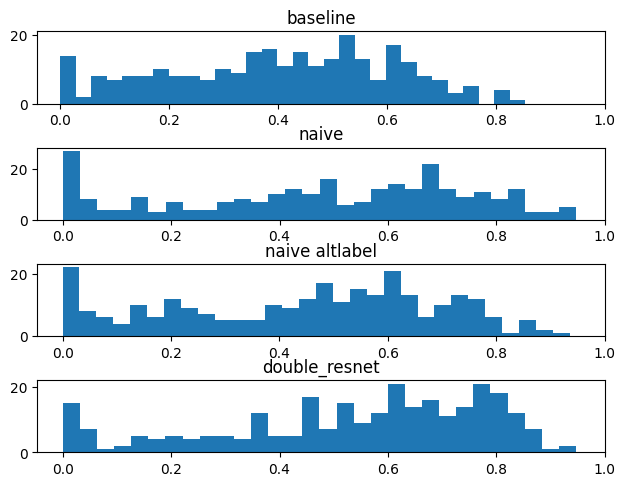

In [13]:
fig, axes = plt.subplots(nrows=4, ncols=1)
fig.tight_layout() 

plt.subplot(4,1,1)
plt.hist(baseline_iou, bins=30)
plt.title("baseline")
plt.xticks([0,0.2,0.4,0.6,0.8,1])

plt.subplot(4,1,2)
plt.hist(naive_iou, bins=30)
plt.title("naive")
plt.xticks([0,0.2,0.4,0.6,0.8,1])

plt.subplot(4,1,3)
plt.hist(naive_altlabel_iou, bins=30)
plt.title("naive altlabel")
plt.xticks([0,0.2,0.4,0.6,0.8,1])

plt.subplot(4,1,4)
plt.hist(doubleres_iou, bins=30)
plt.title("double_resnet")
plt.xticks([0,0.2,0.4,0.6,0.8,1])

plt.show()

In [14]:
print("Mean IOU for baseline: ", sum(baseline_iou)/len(baseline_iou))
print("Mean IOU for naive: ", sum(naive_iou)/len(naive_iou))
print("Mean IOU for naive altlabel: ", sum(naive_altlabel_iou)/len(naive_altlabel_iou))
print("Mean IOU for naive altlabel: ", sum(doubleres_iou)/len(doubleres_iou))

Mean IOU for baseline:  0.40238363005134775
Mean IOU for naive:  0.4741196267410011
Mean IOU for naive altlabel:  0.4392782002315275
Mean IOU for naive altlabel:  0.5384705508903892


In [15]:
example_count = len(baseline_iou)
thresholds = [0.5, 0.75, 0.8, 0.9]
baseline_correct = []
naive_correct = []
naive_altlabel_correct = []
doubleres_correct = []
for threshold in [0.5, 0.75, 0.8, 0.9]:
    baseline_correct.append(len([x for x in baseline_iou if x >= threshold]))
    naive_correct.append(len([x for x in naive_iou if x >= threshold]))
    naive_altlabel_correct.append(len([x for x in naive_altlabel_iou if x >= threshold]))
    doubleres_correct.append(len([x for x in doubleres_iou if x >= threshold]))

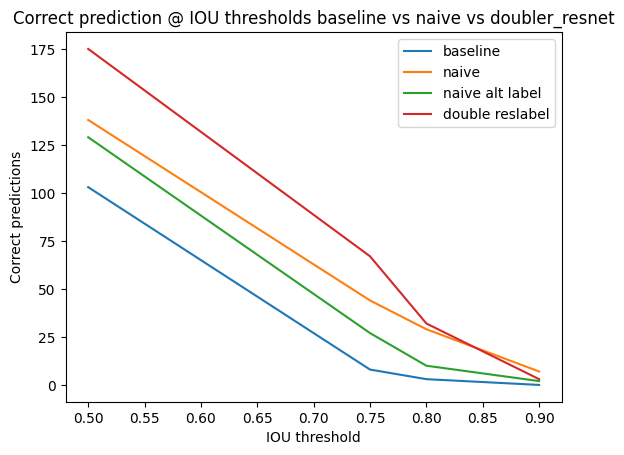

In [16]:
plt.plot(thresholds, baseline_correct,label="baseline")
plt.ylabel("Correct predictions")
plt.xlabel("IOU threshold")
plt.plot(thresholds, naive_correct, label="naive")
plt.plot(thresholds, naive_altlabel_correct, label="naive alt label")
plt.legend(loc="upper right")
plt.title("Correct prediction @ IOU thresholds baseline vs naive vs doubler_resnet")
plt.plot(thresholds, doubleres_correct, label="double reslabel")
plt.legend(loc="upper right")

#plt.savefig("name.png")
plt.show()

In [17]:
baseline_name = [x.split(",")[0] for x in baseline_csv]
naive_name = [x.split(",")[0] for x in naive_csv]
naive_altlabel_name = [x.split(",")[0] for x in naive_altlabel_csv]
doubleres_name = [x.split(",")[0] for x in doubleres_csv]

In [18]:
common_name = [x for x in baseline_name if x in naive_name and x in naive_altlabel_name and x in doubleres_name]

In [19]:
common_name

['2008_004914.jpg']

In [21]:
def get_label(fn,csv_file):
    for line in csv_file:
        line = line.split(",")
        if fn == line[0]:
            return line[1:5]

In [34]:
def get_new_label(xmin, ymin, xmax, ymax):
    xmin, ymin, xmax, ymax = [int(x) for x in [xmin, ymin, xmax, ymax]]
    height = ymax - ymin
    width = xmax - xmin
    x_origin = int(xmin + (width/2))
    y_origin = int(ymin + (height/2))
    return [str(x) for x in [x_origin, y_origin, height, width]]

In [20]:
IMG_DIR = "../../dataset/one_revoc/img/"
OBJ_DIR = "../../dataset/obj_norm/"
LABEL_DIR = "../../dataset/one_revoc_original/img/"

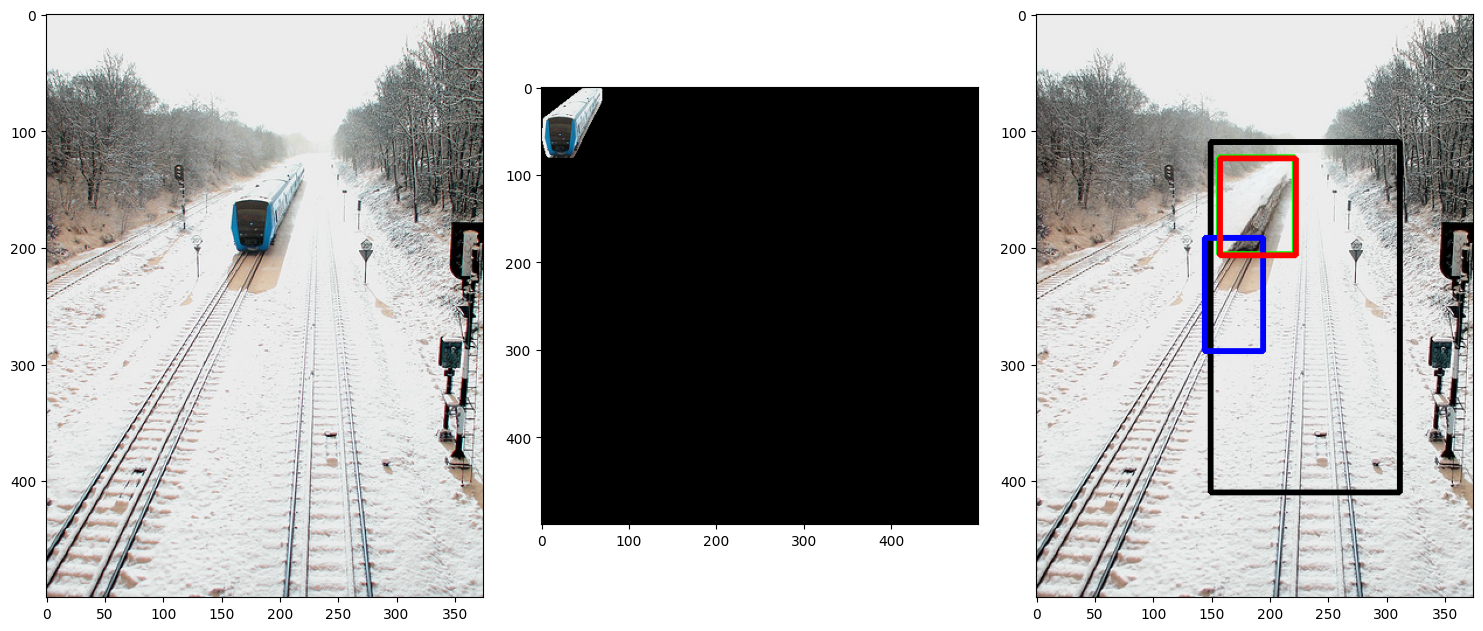

In [22]:
nrows = 1
ncols = 3
fig, axes = plt.subplots(nrows, ncols, figsize=(15,15))
fig.tight_layout()
i = 0

for fn in common_name:
    img_name = os.path.join(IMG_DIR, fn)
    obj_name = os.path.join(OBJ_DIR, fn.split(".")[0]+".png")
    label_name = os.path.join(LABEL_DIR, fn)
    
    label_xmin, label_ymin, label_xmax, label_ymax = [x for x in baseline_csv if x.split(",")[0] == fn][0].split(",")[1:5]
    base_xmin, base_ymin, base_xmax, base_ymax = [x for x in baseline_csv if x.split(",")[0] == fn][0].split(",")[-4:]    
    naive_xmin, naive_ymin, naive_xmax, naive_ymax = [x for x in naive_csv if x.split(",")[0] == fn][0].split(",")[-4:]    
    naive_alt_xmin, naive_alt_ymin, naive_alt_xmax, naive_alt_ymax = [x for x in naive_altlabel_csv if x.split(",")[0] == fn][0].split(",")[5:]
    base_ymax, naive_ymax, naive_alt_ymax = base_ymax.strip(), naive_ymax.strip(), naive_alt_ymax.strip()
    doubleres_xmin, doubleres_ymin, doubleres_xmax, doubleres_ymax = [x for x in doubleres_csv if x.split(",")[0] == fn][0].split(",")[1:5]

    label_xmin, label_ymin, label_xmax, label_ymax = [int(x) for x in [label_xmin, label_ymin, label_xmax, label_ymax]]
    base_xmin, base_ymin, base_xmax, base_ymax = [int(x) for x in [base_xmin, base_ymin, base_xmax, base_ymax]]
    naive_xmin, naive_ymin, naive_xmax, naive_ymax = [int(x) for x in [naive_xmin, naive_ymin, naive_xmax, naive_ymax]]
    naive_alt_xmin, naive_alt_ymin, naive_alt_xmax, naive_alt_ymax = [int(x) for x in [naive_alt_xmin, naive_alt_ymin, naive_alt_xmax, naive_alt_ymax]]
    doubleres_xmin, doubleres_ymin, doubleres_xmax, doubleres_ymax = [int(x) for x in [doubleres_xmin, doubleres_ymin, doubleres_xmax, doubleres_ymax]]
    
    # print("BEFORE",label_xmin, label_ymin, label_xmax, label_ymax)
    label_xmin, label_ymin, label_xmax, label_ymax = get_corners(label_xmin, label_ymin, label_xmax, label_ymax)
    base_xmin, base_ymin, base_xmax, base_ymax = get_corners(base_xmin, base_ymin, base_xmax, base_ymax)
    naive_alt_xmin, naive_alt_ymin, naive_alt_xmax, naive_alt_ymax = get_corners(naive_alt_xmin, naive_alt_ymin, naive_alt_xmax, naive_alt_ymax)

    label_xmin, label_ymin, label_xmax, label_ymax = [int(x) for x in [label_xmin, label_ymin, label_xmax, label_ymax]]
    base_xmin, base_ymin, base_xmax, base_ymax = [int(x) for x in [base_xmin, base_ymin, base_xmax, base_ymax]]
    naive_alt_xmin, naive_alt_ymin, naive_alt_xmax, naive_alt_ymax = [int(x) for x in [naive_alt_xmin, naive_alt_ymin, naive_alt_xmax, naive_alt_ymax]]
    
    img = cv2.imread(img_name)
    obj = cv2.imread(obj_name)
    label = cv2.imread(label_name)

    img = cv2.rectangle(img, (label_xmin, label_ymax), (label_xmax, label_ymin), (0,255,0), 3)
    img = cv2.rectangle(img, (base_xmin, base_ymax), (base_xmax, base_ymin), (0,0,0), 3)
    img = cv2.rectangle(img, (naive_xmin, naive_ymax), (naive_xmax, naive_ymin), (0,0,255), 3)
    #img = cv2.rectangle(img, (naive_alt_xmin, naive_alt_ymax), (naive_alt_xmax, naive_alt_ymin), (255,0,0), 3)
    img = cv2.rectangle(img, (doubleres_xmin, doubleres_ymax),(doubleres_xmax,doubleres_ymin),(255,0,0),3)

    #print(label_xmin, label_ymin, label_xmax, label_ymax)
    
    i += 1
    plt.subplot(nrows, ncols, i)
    plt.imshow(label)
    
    i +=1 
    plt.subplot(nrows, ncols, i)
    plt.imshow(obj)

    i += 1
    plt.subplot(nrows, ncols, i)
    plt.imshow(img)

